In [1]:
import pandas as pd

df = pd.read_csv(
    r"../data/crime_feature_engineered.csv"
)

print(df.shape)
df.head()

(492933, 35)


,ID,Case Number,Date,Block,IUCR,Primary Type,Description,Location Description,Arrest,Domestic,...,IsWeekend,Season,Crime_Severity_Score,Lat_Bin,Lon_Bin,Crime_Type_Encoded,Location_Encoded,District_Encoded,Latitude_Scaled,Longitude_Scaled
0,8466079,HV142615,2012-02-02 15:08:00,066XX S ST LAWRENCE AVE,1811,NARCOTICS,POSS: CANNABIS 30GMS OR LESS,SIDEWALK,True,False,...,0,Winter,2.0,6,15,18,142,15,-0.796001,1.026779
1,10039292,HY229009,2015-04-11 17:30:00,069XX S JUSTINE ST,1310,CRIMINAL DAMAGE,TO PROPERTY,APARTMENT,False,False,...,1,Spring,1.0,6,13,6,17,20,-0.868525,0.144205
2,8656424,HV331830,2012-06-12 21:21:00,051XX W NORTH AVE,041A,BATTERY,AGGRAVATED: HANDGUN,PARKING LOT/GARAGE(NON.RESID.),False,False,...,0,Summer,3.0,14,8,2,114,14,0.771923,-1.421922
3,1527209,G277177,2001-05-13 23:30:00,044XX S INDIANA AV,0915,MOTOR VEHICLE THEFT,"TRUCK, BUS, MOTOR HOME",STREET,False,False,...,1,Spring,3.0,8,15,17,147,10,-0.324950,0.842742
4,1583223,G348885,2001-06-12 07:00:00,060XX S FRANCISCO AV,0810,THEFT,OVER $500,RESIDENCE,False,True,...,0,Summer,2.0,7,11,31,121,21,-0.687510,-0.422679


In [2]:
X = df[['Latitude_Scaled', 'Longitude_Scaled']]

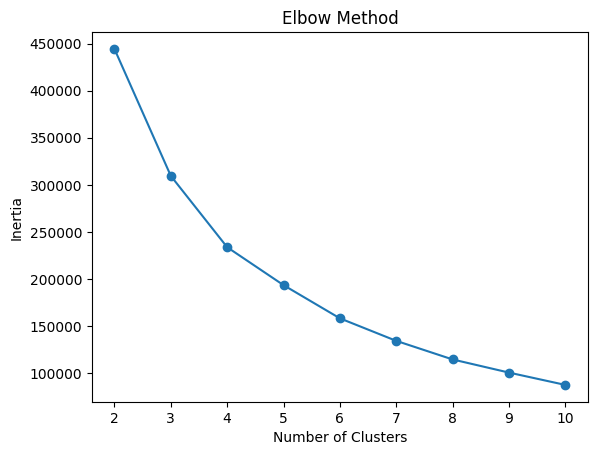

In [3]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

for k in range(2, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X)

    inertia.append(kmeans.inertia_)

plt.plot(range(2,11), inertia, marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

In [4]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(
    eps=0.08,
    min_samples=20
)

df['DBSCAN_Cluster'] = dbscan.fit_predict(X)

In [5]:
print(df['DBSCAN_Cluster'].value_counts())

DBSCAN_Cluster
 0    489946
 1      1829
 2       908
-1       113
 3        83
 4        54
Name: count, dtype: int64


In [6]:
sample_hier = df.sample(
    n=5000,
    random_state=42
)

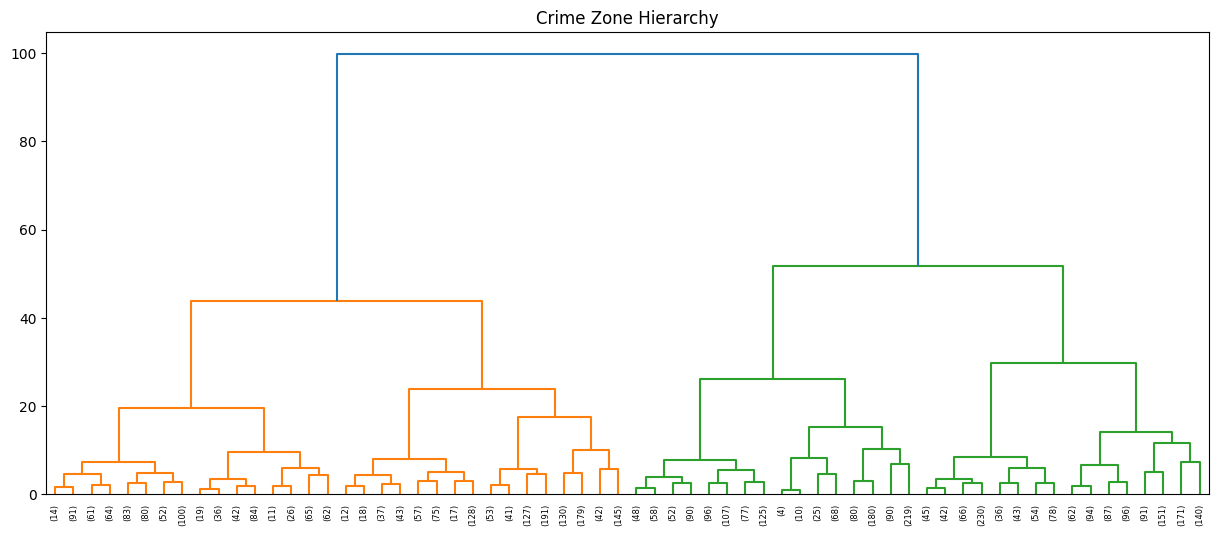

In [7]:
from scipy.cluster.hierarchy import linkage, dendrogram
import matplotlib.pyplot as plt

X_hier = sample_hier[
    ['Latitude_Scaled','Longitude_Scaled']
]

linked = linkage(
    X_hier,
    method='ward'
)

plt.figure(figsize=(15,6))

dendrogram(
    linked,
    truncate_mode='level',
    p=5
)

plt.title("Crime Zone Hierarchy")
plt.show()

In [8]:
#Evalution

In [9]:
eval_sample = df.sample(
    n=50000,
    random_state=42
)

X_eval = eval_sample[
    ['Latitude_Scaled', 'Longitude_Scaled']
]

In [10]:
from sklearn.metrics import silhouette_score, davies_bouldin_score

kmeans = KMeans(
    n_clusters=10,
    random_state=42,
    n_init=10
)

labels = kmeans.fit_predict(X_eval)

sil = silhouette_score(X_eval, labels)

dbi = davies_bouldin_score(X_eval, labels)

print("Silhouette:", sil)
print("DBI:", dbi)

Silhouette: 0.4098465627913522
DBI: 0.7734220743763054


In [11]:
results = []

for k in range(2, 10):

    for init in ['k-means++', 'random']:

        for n_init in [10, 20, 50]:

            for max_iter in [300, 500]:

                km = KMeans(
                    n_clusters=k,
                    init=init,
                    n_init=n_init,
                    max_iter=max_iter,
                    random_state=42
                )

                labels = km.fit_predict(X_eval)

                score = silhouette_score(
                    X_eval,
                    labels
                )

                results.append([
                    k,
                    init,
                    n_init,
                    max_iter,
                    score
                ])

results_df = pd.DataFrame(
    results,
    columns=[
        'k',
        'init',
        'n_init',
        'max_iter',
        'silhouette_score'
    ]
)

results_df = results_df.sort_values(
    by='silhouette_score',
    ascending=False
)

print(results_df.head(20))

KeyboardInterrupt: 

In [12]:
# Remove noise points
dbscan_data = df[df['DBSCAN_Cluster'] != -1]

# Take evaluation sample
dbscan_sample = dbscan_data.sample(
    n=50000,
    random_state=42
)

X_dbscan = dbscan_sample[
    ['Latitude_Scaled', 'Longitude_Scaled']
]

labels_dbscan = dbscan_sample['DBSCAN_Cluster']

sil_dbscan = silhouette_score(
    X_dbscan,
    labels_dbscan
)

dbi_dbscan = davies_bouldin_score(
    X_dbscan,
    labels_dbscan
)

print("DBSCAN Silhouette:", sil_dbscan)
print("DBSCAN DBI:", dbi_dbscan)

DBSCAN Silhouette: 0.2764650565520594
DBSCAN DBI: 0.41666166614289935


In [13]:
from sklearn.cluster import AgglomerativeClustering

X_hier = sample_hier[
    ['Latitude_Scaled','Longitude_Scaled']
]

hier = AgglomerativeClustering(
    n_clusters=6
)

hier_labels = hier.fit_predict(X_hier)

sil_hier = silhouette_score(
    X_hier,
    hier_labels
)

dbi_hier = davies_bouldin_score(
    X_hier,
    hier_labels
)

print("Hierarchical Silhouette:", sil_hier)
print("Hierarchical DBI:", dbi_hier)

Hierarchical Silhouette: 0.35924413876057715
Hierarchical DBI: 0.8225721637953907


In [14]:
from sklearn.preprocessing import StandardScaler

temporal_df = df[
    [
        'Hour',
        'Month',
        'IsWeekend'
    ]
]

scaler = StandardScaler()

X_temporal = scaler.fit_transform(
    temporal_df
)

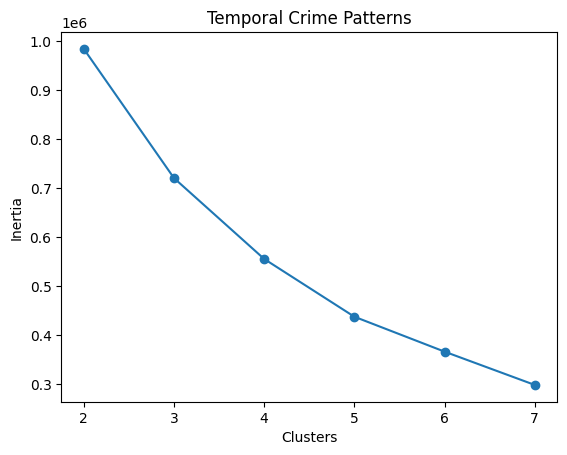

In [15]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

for k in range(2, 8):

    km = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    )

    km.fit(X_temporal)

    inertia.append(km.inertia_)

plt.plot(
    range(2,8),
    inertia,
    marker='o'
)

plt.xlabel("Clusters")
plt.ylabel("Inertia")
plt.title("Temporal Crime Patterns")
plt.show()

In [16]:
kmeans_temporal = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=20
)

df['Temporal_Cluster'] = (
    kmeans_temporal.fit_predict(
        X_temporal
    )
)

In [17]:
eval_temporal = df.sample(
    n=50000,
    random_state=42
)

In [18]:
X_eval = eval_sample[
    [
        'Hour',
        'Month',
        'IsWeekend'
    ]
]

X_eval = scaler.fit_transform(X_eval)

labels = kmeans_temporal.predict(X_eval)

sil = silhouette_score(
    X_eval,
    labels
)

dbi = davies_bouldin_score(
    X_eval,
    labels
)

print("Silhouette Score:", sil)
print("Davies-Bouldin Index:", dbi)

Silhouette Score: 0.3612662197961362
Davies-Bouldin Index: 0.879990686240802


In [19]:
cluster_summary = (
    df.groupby(
        'Temporal_Cluster'
    )
    [
        [
            'Hour',
            'Month',
            'IsWeekend'
        ]
    ]
    .mean()
)

print(cluster_summary)

                       Hour     Month  IsWeekend
Temporal_Cluster                                
0                  4.240440  6.806055        0.0
1                 12.589801  6.630461        1.0
2                 15.997533  3.473076        0.0
3                 16.378217  9.533973        0.0


In [20]:
print(
    df['Temporal_Cluster']
    .value_counts()
    .sort_index()
)

Temporal_Cluster
0     85643
1    137972
2    134562
3    134756
Name: count, dtype: int64


In [21]:
for cluster in sorted(
    df['Temporal_Cluster'].unique()
):

    print("\n")
    print("="*50)
    print(f"Cluster {cluster}")
    print("="*50)

    print(
        df[
            df['Temporal_Cluster']==cluster
        ]['Primary Type']
        .value_counts()
        .head(10)
    )



Cluster 0
Primary Type
THEFT                  17338
BATTERY                15360
CRIMINAL DAMAGE        11714
BURGLARY                6642
OTHER OFFENSE           5437
MOTOR VEHICLE THEFT     5100
ASSAULT                 4776
DECEPTIVE PRACTICE      4618
NARCOTICS               4028
ROBBERY                 3621
Name: count, dtype: int64


Cluster 1
Primary Type
BATTERY                29184
THEFT                  27890
CRIMINAL DAMAGE        17471
NARCOTICS              11147
ASSAULT                 9030
OTHER OFFENSE           8232
MOTOR VEHICLE THEFT     7391
BURGLARY                6366
ROBBERY                 5503
DECEPTIVE PRACTICE      4600
Name: count, dtype: int64


Cluster 2
Primary Type
THEFT                  28299
BATTERY                23475
NARCOTICS              15072
CRIMINAL DAMAGE        13432
ASSAULT                 9751
OTHER OFFENSE           9255
BURGLARY                6438
DECEPTIVE PRACTICE      6381
MOTOR VEHICLE THEFT     6262
ROBBERY                 4409
Nam

In [22]:
hourly_crime = (
    df.groupby('Hour')
      .size()
      .reset_index(name='Crime_Count')
)

print(
    hourly_crime.sort_values(
        'Crime_Count',
        ascending=False
    ).head(10)
)

    Hour  Crime_Count
12    12        28263
19    19        27731
0      0        27648
20    20        27611
18    18        27032
21    21        26753
15    15        26186
22    22        25974
17    17        25618
14    14        24922


In [23]:
seasonal_crime = (
    df.groupby('Season')
      .size()
      .reset_index(name='Crime_Count')
)

print(
    seasonal_crime.sort_values(
        'Crime_Count',
        ascending=False
    )
)

   Season  Crime_Count
2  Summer       136094
0    Fall       125843
1  Spring       124737
3  Winter       106259


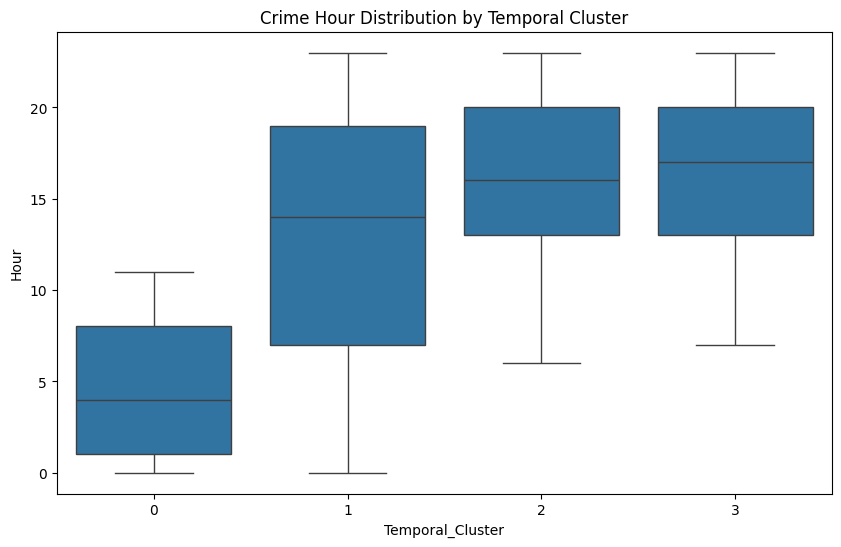

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

sns.boxplot(
    data=df,
    x='Temporal_Cluster',
    y='Hour'
)

plt.title(
    "Crime Hour Distribution by Temporal Cluster"
)

plt.show()

In [27]:
from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=10,
    random_state=42
)

df["KMeans_Cluster"] = kmeans.fit_predict(
    df[["Latitude_Scaled", "Longitude_Scaled"]]
)

In [28]:
df.to_csv(
    "../data/crime_clustered_final.csv",
    index=False
)

print("Final dataset saved successfully!")

Final dataset saved successfully!


In [31]:
sample_df = df.sample(
    n=50000,
    random_state=42
)

sample_df.to_csv(
    "../data/crime_clustered_final.csv",
    index=False
)